Análisis del desempeño de modelos -- Parte 1
===

El análisis del desempeño de modelos se utiliza principalmente para retroalimentar el proceso de modelado tanto en calidad como en precisión. Las métricas de desempeño se definen de acuerdo a cada problema y al enfoque de cada solución, partiendo de los algoritmos implementados en cada caso. El tratamiento estadístico inicial de los datos, generalmente, impacta en las medidas de desempeño de un modelo, dentro de estas técnicas resaltan el muestreo de los datos de entrenamiento, las pruebas de hipótesis para estimación de parámetros y el ajuste distribuciones.

Al finalizar este tutorial, usted estará en capacidad de:

* Definir qué es una muestra y cuales son los tipos de muestreo. 


* Definir y calcular intervalos de confianza.


* Explicar el concepto de boostrapping y sus derivados.


* Explicar como afecta a un modelo la partición de los datos y el muestreo.


## Definición de conceptos básicos

#### Población

Colección de objetos o individuos sobre los cuales se desea obtener información de interés.

#### Muestra

Grupo obtenido aleatoriamente que es representativo de la población.

#### Parámetro

Un valor que resume una propiedad o característica de la población entera. 

#### Muestreo sin reemplazo

Cuando una observación es seleccionada ya no está disponible en adelante. 

#### Muestreo con reemplazo

Cada observación es devuelta a la población después de ser seleccionada.

#### Muestreo aleatorio

Muestreo de elementos de forma aleatoria tal que cada miembro de la población tiene igual probabilidad de ser seleccionado.

#### Muestreo estratificado

División de la población en estratos y muestreo aleatorio de cada estrato.

#### Muestra aleatoria simple

Muestra que resulta de muestrear la población sin estratificar.

#### Muestra sesgada

Muestra que no representa la población.

#### Sesgo estadístico

Errores de muestreo o medición que son sistemáticos y producidos por la medición o el muestreo mismo.

#### Estadístico

Un número que resume una propiedad o característica de la muestra. 

## Distribución muestral de un estadístico

#### Estadístico muestral

Una métrica calculada para una muestra de datos obtenida de forma aleatoria de la población.

#### Distribución muestral

Es la distribución de probabilidad de un estadístico muestral calculado sobre muchas muestras o remuestreos

#### Error estándar
Es la desviación estándar del estadístico muestral sobre muchas muestras.



Para estimar el valor de un parámetro de la población mediante un estadístico calculado sobre la muestra, se deben tener en cuenta alguna de las dos siguientes opciones: 

* Pruebas de hipótesis (se caracterizaron en el módulo de análisis exploratorio).

* Estimación de intervalos de confianza.

## Intervalos de confianza

Ya que el estadístico $\theta$ es una aproximación al valor real del parámetro $\Theta$ de la población, se establece un intervalo de confianza, tal que:

$$\theta_L < \theta < \theta_U$$ 

en que se cree se encuentra el verdadero valor del parámetro de la población $\Theta$. Usualmente, se plantea en términos del márgen de error (y un intervalo de confianza):

$$\text{Estadístico}  \pm \text{error}$$

## Teorema del Límite Central

Si $x_1$, ..., $x_n$ es una muestra aleatoria donde las observaciones $x_i$ son independientes e identicamente distribuidas de una distribución con media $\mu$ y varianza finita $\sigma^2$, entonces:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$$

sigue una distribución normal con media $\mu$ y varianza $(\sigma_{\bar{x}})^2 = \sigma^2 / n$.

Note que no se hace ningún supuesto sobre la distribución que siguen las observaciones $x_i$

---
**Actividad.--** Genere una muestra de 15 números aleatorios uniformes en el intervalo $[0, 5]$ y calcule su media. Repita el ejercicio 500 veces y grafique el histograma de las medias. Encima grafique la distribución normal teórica y compare.

En este ejemplo y dado el conocimiento previo sobre la distribución de probabilidades, se espera que la media de un conjunto de números aleatorios uniformes en el intervalo  $[0, 5]$ sea 2.5; no obstante, el valor calculado es dependiente de la datos que conforman la muestra y no es real que simpre sea 2.5. Es así como en este ejemplo, se generan muestras aleatorias de 15 datos para las cuales se computa su media.

In [2]:
medias <- c()                                    ## se crea un vector para almacenar las medias
for (i in seq(1,500,1)){
    medias[i] <- mean(runif(15,min = 0, max=5))  ## se genera la media de 15 números aleatorios uniformes 
}

La distribución de probabilidades que sigue la muestra de las medias, está dada por el Teorema del Límite Central. Esta es una distribución normal la misma media de la distribución uniforme en el intervalo $[0, 5]$ y una varianza igual a la varianza de la distribución uniforme en el intervalo $[0, 5]$ divida por 300.

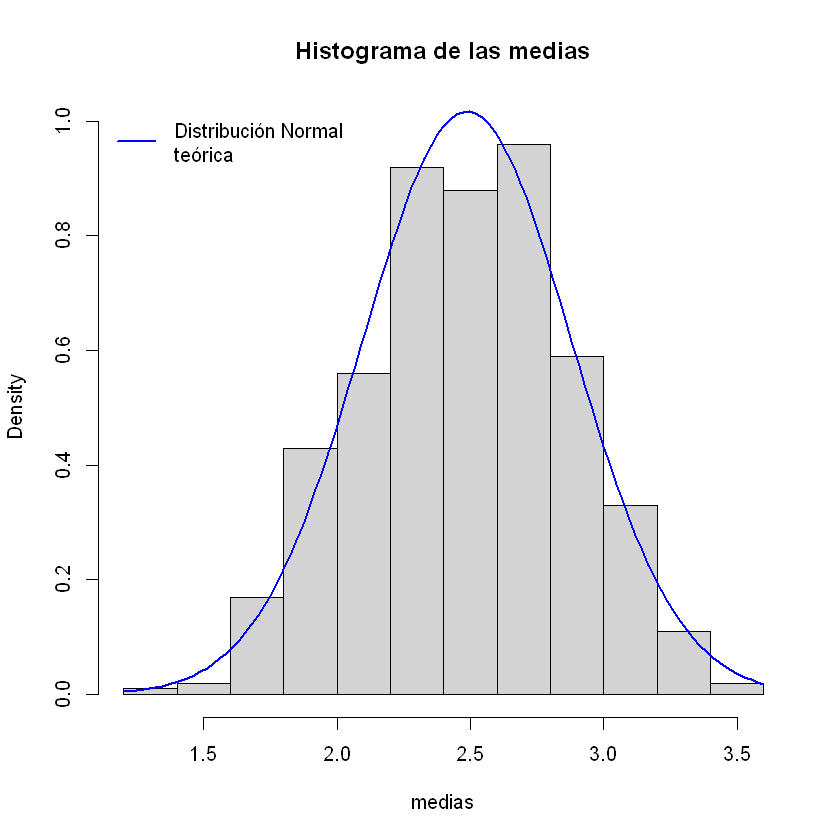

In [5]:
##
## A continuación se realiza el histograma de las 500 medias calculadas.
## Observe que la distribución de las medias, ## se comporta como una 
## distribución normal. 
##
hist(medias, probability = TRUE,                   ## histograma
     main= "Histograma de las medias", 
     col="lightgray", ylim=c(0,1)) 

curve(dnorm(x, mean=mean(medias), sd=sd(medias)),  ## Distribución normal
      add=TRUE, col="blue", lwd=2)                   

legend("topleft",col=c("blue"),
       legend =c("Distribución Normal 
teórica"),lwd=2, bty = "n")

---

## Bootstrapping

El bootstrap se usa para estimar la distribución de probabilidades de un estadístico cuando  no es posible derivar ecuaciones teóricas. El bootstrap se basa en el remuestreo de los datos para poder obtener una muestra del estadístico que se está calculado. 

Supoga que tiene una muestra de ocho ejemplos:

$$\{x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8\}$$

Una muestra bootstap se obtiene de la muestra original, seleccionando ocho elementos de forma aleatoria con reemplazo. Por ejemplo, una muestra bootstrap podría ser:

$$\{x_1, x_2, x_2, x_2, x_4, x_1, x_7, x_7\}$$

Nóte que los elementos pueden repetirse. Sobre cada muestra bootstrap obtenida, se realiza el proceso de cómputo y se obtiene el estadístico de interés. Si este procedimiento se repite 500 veces para calcular el estadístico de interés, se tenddrían 500 valores posibles de éste. Así, una estimación mucho mejor del valor del estadístico, sería calcular su valor promedio a partir de la muestra de 500 valores. Más aún, podría calcularse el histograma o la distribución de probabilidades de dicho estadístico, lo cual es mucho más informativo.

---
**Actividad.--** Se tiene la siguiente muestra de datos:

    0.09 0.15 0.18 0.23 0.35 0.49 0.68 0.71 0.85 0.96 0.98
    
    
Compute la media y sus intervalos de confianza usando el Teorema del Límite Central y bootstrap con 500 repeticiones.

In [6]:
x <- c(0.09,0.15,0.18,0.23,0.35,0.49,0.68,0.71,0.85,0.96,0.98)

In [7]:
##
## Se calculan los intervalos de confianza 
## para la media para una confianza del 95% 
## usando el Teorema del Límite Central
##
library(DescTools)
MeanCI(x,
       conf.level=0.95) 

mean    lwr.ci    upr.ci 
0.5154545 0.2899354 0.7409737

In [14]:
##
## Estimación mediante bootstrap
##

## se carga la librería
library(boot)                             

## se realiza la estimación de la media con 500 repeticiones
mean_est <- boot(x,                      
             function(x,i) mean(x[i]), 
             R=500)

## media estimada con el método
mean(mean_est$t[,1])                      

[1] 0.5162327

In [16]:
##
## Se calculan los intervalos de confianza.
## Note que los intervalos calculados son similares
## a los computados usando el Teorema del Límite 
## Central; para mejorar la aproximación se debe
## aumentar la cantidad de muestras bootstrap usadas
##
boot.ci(mean_est,                               ## se utiliza la función boot.ci para estimar los intervalos de confianza
        conf = 0.95,                            ## con una confianza del 95% 
        type = c("basic"))                      ## se seleccionan intervalos básicos

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 500 bootstrap replicates

CALL : 
boot.ci(boot.out = mean_est, conf = 0.95, type = c("basic"))

Intervals : 
Level      Basic         
95%   ( 0.3400,  0.6953 )  
Calculations and Intervals on Original Scale

### Algoritmo bootstrap no paramétrico

* Se tiene la muestra $x=\{x_i; 1,...,n\}$


* Se seleccionan $B$ muestras bootstrap independientes $x^{*1}, ..., x^{*B}$ cada una de $n$ elementos obtenidos de la muestra original.


* Para cada muestra bootstap se calcula el estadístico de interes: $\theta(b) = t(x^{*b})$


* La muestra $\theta(1), ..., \theta(B)$ representa la distribución de probabilidades de $\theta$ y puede calcularsele valor esperado, desviación estándar, etc.

* El error estándar se puede calcular como:

$$\text{se}_B = \left\{
\frac{1}{B-1} \sum_{b=1}^B \left[\theta(b) - \bar{\theta}(\bullet) \right]^2
\right\}^{(1/2)}$$

$$
\bar{\theta}(\bullet) = \frac{1}{B} \sum_{b=1}^B \theta (b)$$

## Jackknife

Se obtiene al dejar un solo elemento fuera de la muestra de datos. Esta técnica se usa cuando es muy costoso el proceso de cómputo.


* Se tiene la muestra $x=\{x_i; 1,...,n\}$


* Se calcula el estadístico de interes: $\theta(b) = t(x)$


* Se obtienen $n$ muestras jackknife $x_{(i)}$, $i=1, ...,n$, donde:

$$x_{(i)} = (x_1, \; x_2, \; ..., \; x_{i-1}, \; x_{i+1}, \; ..., \; x_n)$$


* Se calcula el estadístico para la muestra jackknife:

$$\theta_{(i)} = t(x_{(i)})$$


* El error estándar se obtiene como:

$$\text{se}_{\text{jack}} = \left\{
\frac{n-1}{n} \sum_{i=1}^n \left[   \theta_{(i)} - \theta_{(\bullet)}  \right]^2
\right\}^{1/2}$$

$$
\bar{\theta}(\bullet) = \frac{1}{n} \sum_{i=1}^n \theta_{(i)}$$

## Partición de los datos

Los resultados de la evaluación de los modelos es dependiente de los datos usados. En la práctica, los datos se suelen partir en tres conjuntos, tal como muestra la gráfica de abajo:


* Conjunto de calibración de parámetros del modelo.


* Conjunto de prueba, usado comunmente para determinar la complejidad del modelo o el valor óptimo de alguno de sus parámetros.


* Conjunto de pronóstico, en el que se intenta reproducir el comportamiento del modelo en producción.

![alt text](images/model-performance/data-partition.jpg)

En la figura anterior, los datos se dividen secuencialmente, pero podría construirse cada conjunto aletaoriamente. Si se tiene en cuenta que hay muchas particiones aleatorias posibles, una mejor estimación de la matriz de confusión (o cualquier otro estadístico que se calcule para un conjunto de datos) podría ser tomando los valores esperados de cada métrica. Es decir, si se repite el experimento $N$ veces, se tendrían $N$ valores posibles para cada uno de los elementos de la matriz de confusión y por lo tanto se podría tener su valor medio. Esta sería una métrica mucho más apropiada. A continuación se describen varios mecanismos para gestionar la forma en que los datos son particionados.

### Bootstrap

En la práctica resulta inapropiado para modelos con un alto costo computacional, ya que el bootstrap requiere un número grande de réplicas para garantizar la precisión de sus resultados.

### K-fold crossvalidation

En este método, el conjunto de datos para entrenamiento (ajuste + prueba) es dividido en $K$ grupos. Este es un proceso iterativo que opera de la siguiente forma (véase la figura de abajo). 


* Se toma el grupo 1 como conjunto de datos de prueba (grupo rojo) y se entrena el modelo con los grupos restantes {2, ..., $K$} (grupo negro).


* Se toma el grupo 2 como conjunto de datos de prueba (grupo rojo) y se entrena el modelo con los grupos restantes {1, 3, ..., $K$} (grupo negro).


* Se continua de esta forma hasta que se usa el grupo $K$ para prueba, mientras que se usan los grupos 1 hasta $K$-1 para entrenamiento.

![alt text](images/model-performance/k-fold-crossval.jpg)

De esta forma, se tienen $K$ valores posibles para el estadístico de interés. Usualmente se reporta su valor promedio.

Note que una mejor opción sería distribuir los datos en cada grupo de forma aleatoria en vez de tomarlos secuencialmente.

### Leave-one-out

Este es el K-fold con $K$ igual a la cantidad de datos, tal como se ilustra en la figura de abajo. El método opera igual que *K-fold crossvalidation*, pero dejando un patrón fuera cada vez.

![alt text](images/model-performance/leave-one-out.jpg)

## Afinación de los parámetros de modelos

Como ya se discutio, un modelo puede tener un conjunto de parámetros ajustables para su especificación. La afinación consiste en calcular las métricas de desempeño del modelo para diferentes valores de sus parámetros de forma similar a como se realizaría si fuese un diseño de experimentos. 

Supóngase que el modelo $m$ tiene dos parámetros ajustables $A$ y $B$; y que ellos pueden tomar los valores posibles de $A_1$, $A_2$ y $A_3$, y de $B_1$ y $B_2$ respectivamente. En el proceso de afinación de los parámetros se estima el modelo y se eválua su desempeño para las siguientes combinaciones de valore para los parámetros ajustables: ($A_1$, $B_1$), ($A_1$, $B_2$), ($A_2$, $B_1$), ($A_2$, $B_2$), ($A_3$, $B_1$) y  ($A_3$, $B_2$). 

Ya que para cada combinación ($A_i$, $B_j$), el valor del estadístico usado para medir el desempeño es dependiente de la partición de los datos, su valor es estimado usando bootstrap o k-fold crossvalidation. 

---